In [12]:

# salary prediction using Linear regression, Polynomial regression.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
df=pd.read_csv(r"C:\Users\onc\Downloads\Salary Data.csv")
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [14]:
df.shape

(375, 6)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [16]:
df.describe(include=object)

,Gender,Education Level,Job Title
count,373,373,373
unique,2,3,174
top,Male,Bachelor's,Director of Marketing
freq,194,224,12


In [17]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [18]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [19]:
df.dropna(inplace=True)

In [20]:
print(df.duplicated().sum())

49


In [21]:
df[df.duplicated()]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
195,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
250,30.0,Female,Bachelor's,Junior Marketing Coordinator,2.0,40000.0
251,38.0,Male,Master's,Senior IT Consultant,9.0,110000.0
252,45.0,Female,PhD,Senior Product Designer,15.0,150000.0
253,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0
254,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
255,44.0,Male,Bachelor's,Senior Software Engineer,14.0,130000.0
256,34.0,Female,Master's,Senior Financial Advisor,6.0,100000.0
257,35.0,Male,Bachelor's,Senior Project Coordinator,9.0,95000.0
258,50.0,Female,PhD,Director of Operations,22.0,180000.0


In [23]:
df.drop_duplicates(inplace=True)

In [25]:
df.shape

(324, 6)

In [26]:
print(df.duplicated().sum())

0


In [27]:
df.nunique()

Age                     31
Gender                   2
Education Level          3
Job Title              174
Years of Experience     28
Salary                  36
dtype: int64

In [28]:
df['Age']=df['Age'].astype(int) # converting the age column to integer type

In [29]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
348,28,Female,Bachelor's,Junior Operations Manager,1.0,35000.0
349,36,Male,Bachelor's,Senior Business Development Manager,8.0,110000.0
350,44,Female,PhD,Senior Data Scientist,16.0,160000.0
351,31,Male,Bachelor's,Junior Marketing Coordinator,3.0,55000.0
371,43,Male,Master's,Director of Operations,19.0,170000.0


In [ ]:
# EDA

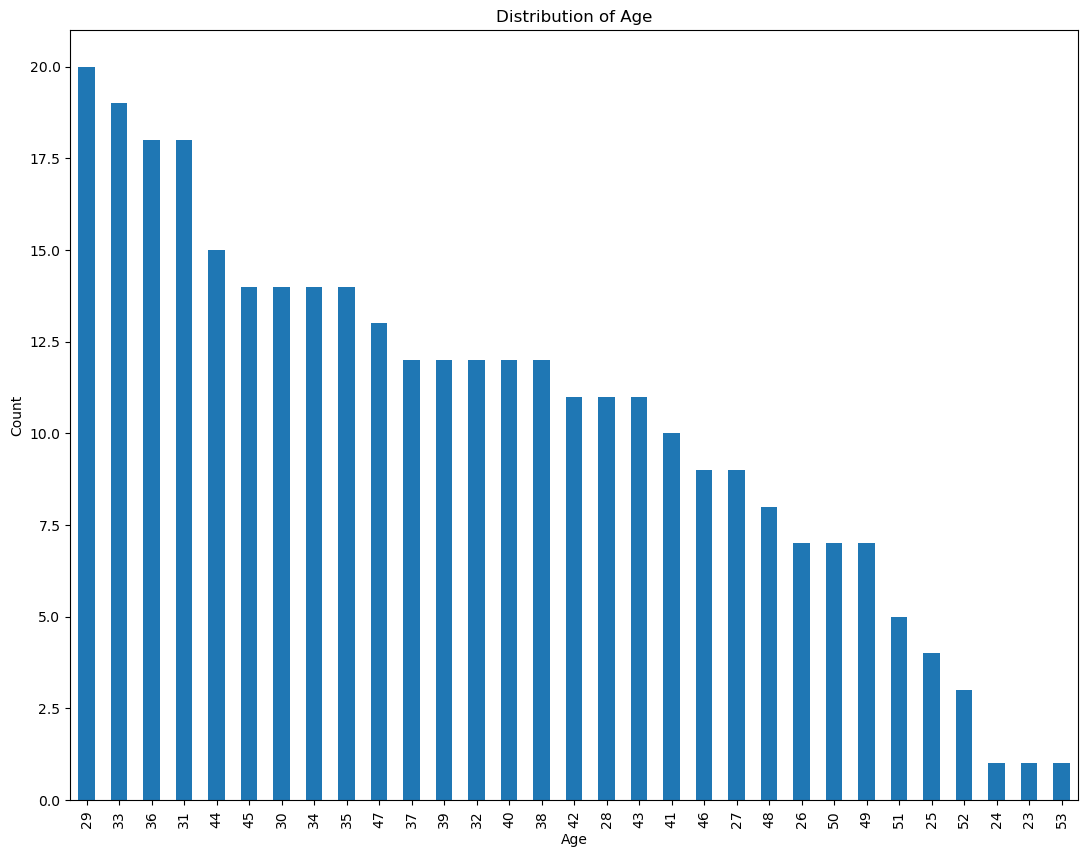

In [30]:
plt.figure(figsize=(13, 10))
df['Age'].value_counts().plot(kind='bar')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Distribution of Age')
plt.show()

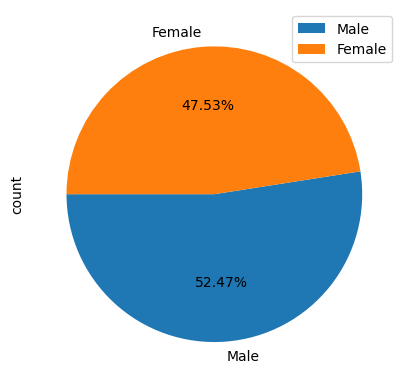

In [31]:
var=df['Gender'].value_counts()
var.plot(kind='pie',autopct="%.2f%%",startangle=180,legend=True)
plt.show()

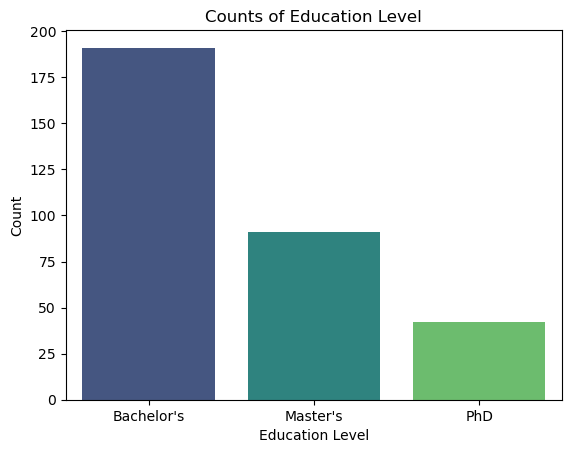

In [32]:
sns.countplot(data=df, x='Education Level', palette='viridis',hue='Education Level', legend=False)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Counts of Education Level')
plt.show()

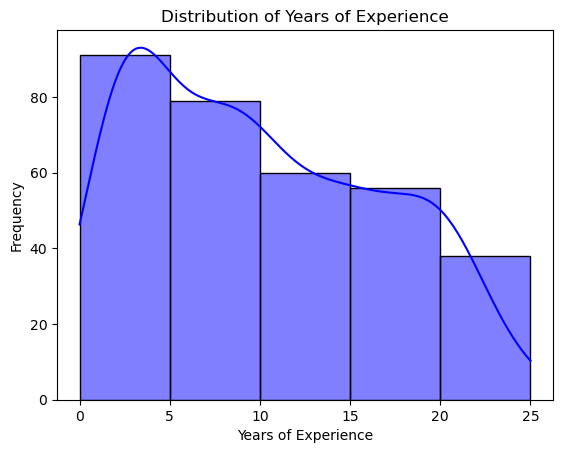

In [33]:
sns.histplot(data=df, x='Years of Experience', kde=True, color='blue', bins=5)
plt.xlabel('Years of Experience')
plt.ylabel('Frequency')
plt.title('Distribution of Years of Experience')
plt.show()

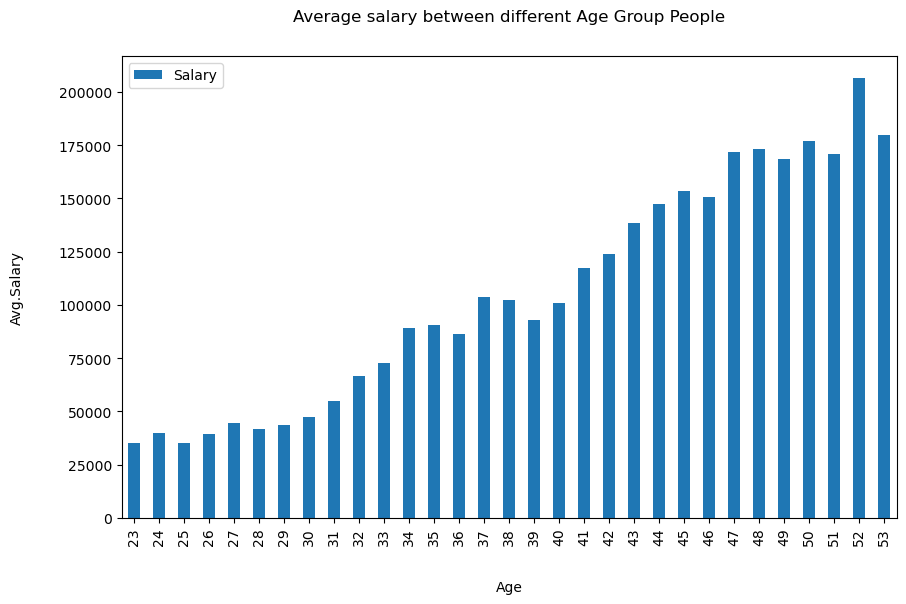

In [35]:
df[['Age','Salary']].groupby('Age').mean().plot(kind='bar',figsize=(10,6))
plt.title('Average salary between different Age Group People',pad=25)
plt.xlabel('Age',labelpad=25)
plt.ylabel('Avg.Salary',labelpad=25)
plt.show()

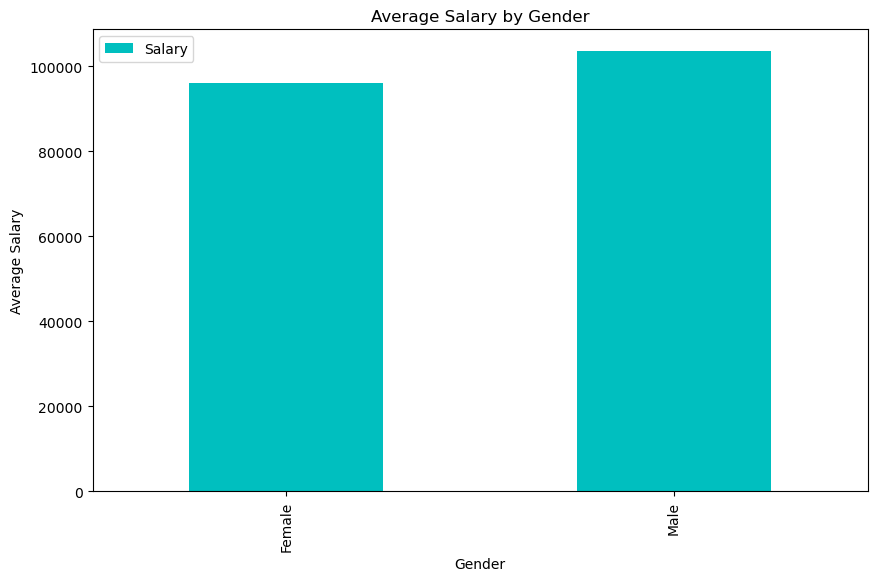

In [36]:
df[['Gender','Salary']].groupby('Gender').mean().plot(kind='bar',figsize=(10,6),color='c')
plt.xlabel('Gender')
plt.ylabel('Average Salary')
plt.title('Average Salary by Gender')
plt.show()

In [37]:
var=df[['Education Level','Salary']].groupby('Education Level').mean()
var

,Salary
Education Level,
Bachelor's,73902.356021
Master's,127912.087912
PhD,158095.238095


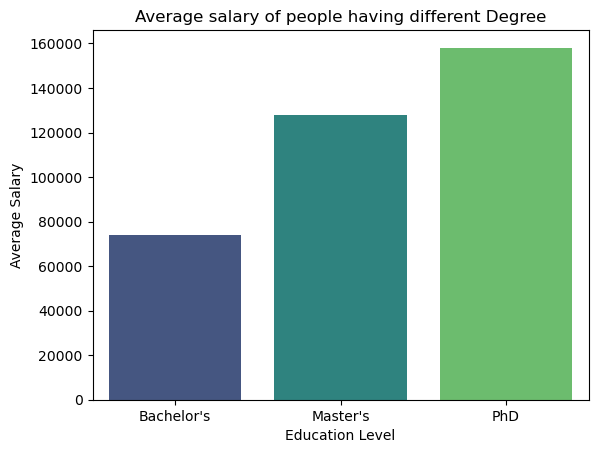

In [38]:
sns.barplot(data=var,x='Education Level', y='Salary',palette='viridis', legend=False, hue='Education Level')
plt.title("Average salary of people having different Degree")
plt.xlabel('Education Level')
plt.ylabel('Average Salary')
plt.show()

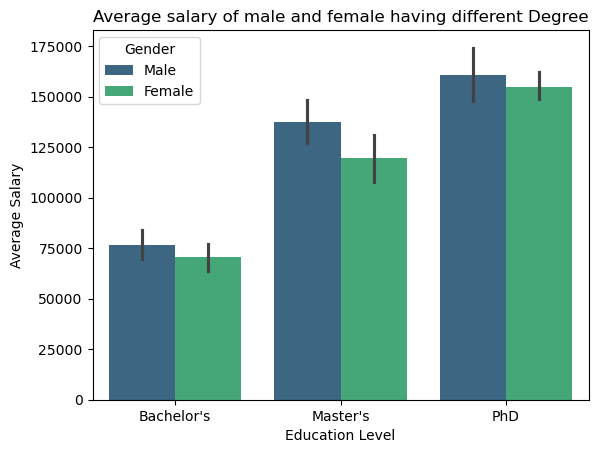

In [39]:
sns.barplot(data=df,x='Education Level', y='Salary',hue='Gender',palette='viridis')
plt.title("Average salary of male and female having different Degree")
plt.xlabel('Education Level')
plt.ylabel('Average Salary')
plt.show()

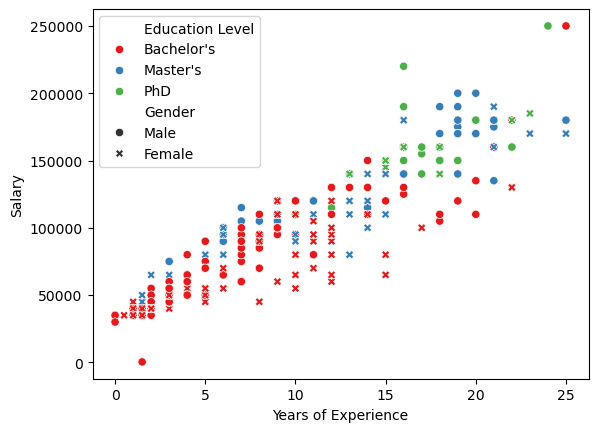

In [40]:
sns.scatterplot(data=df,x='Years of Experience',y='Salary',hue='Education Level',style='Gender',palette='Set1')
plt.show()

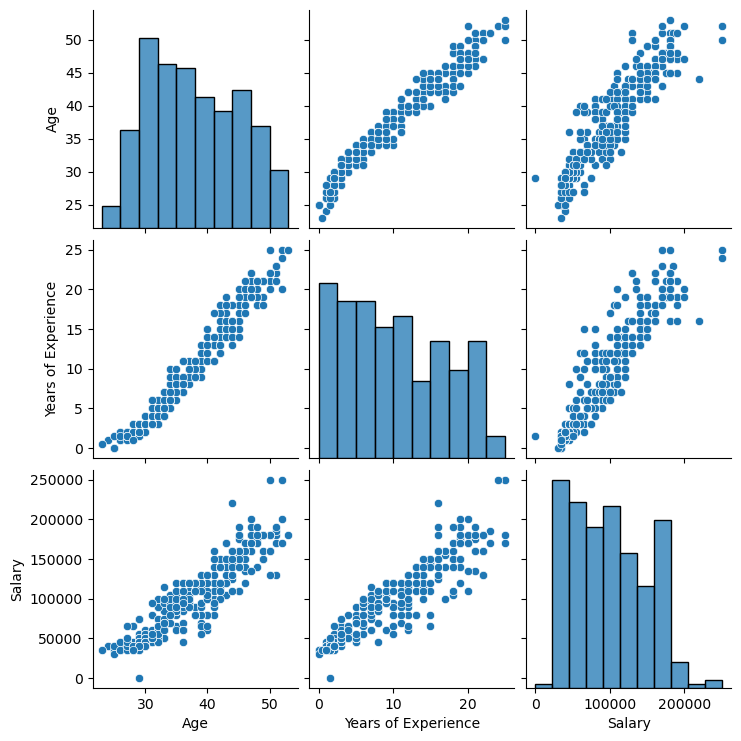

In [41]:
sns.pairplot(data=df)
plt.show()

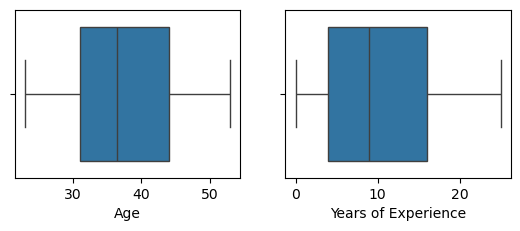

In [42]:
plt.subplot(2,2,1)
sns.boxplot(x=df["Age"])
plt.subplot(2,2,2)
sns.boxplot(x=df["Years of Experience"])
plt.show()


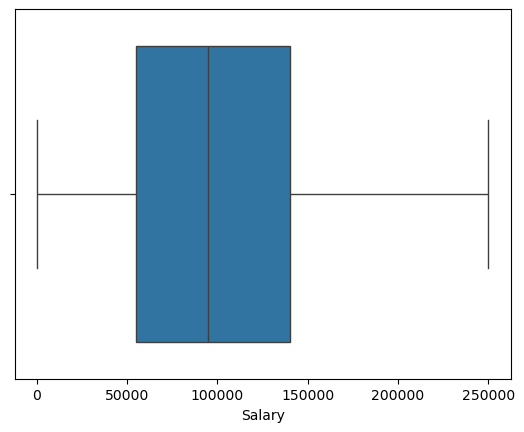

In [43]:
sns.boxplot(x=df["Salary"])
plt.show()

In [44]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28,Female,Master's,Data Analyst,3.0,65000.0
2,45,Male,PhD,Senior Manager,15.0,150000.0
3,36,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52,Male,Master's,Director,20.0,200000.0


In [45]:
df.drop('Job Title',axis=1,inplace=True)

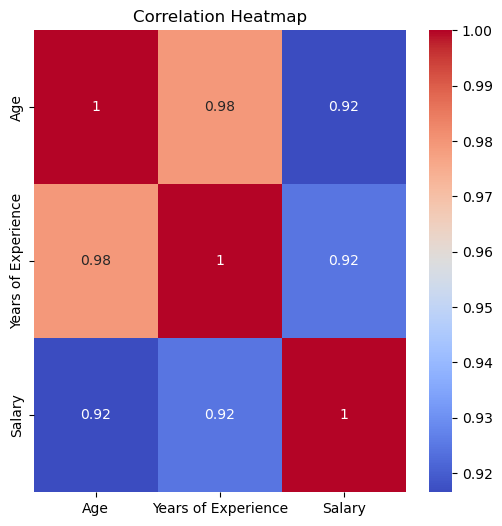

In [49]:
plt.figure(figsize=(6, 6))
df_num = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [47]:
target_col = "Salary"  
corr_matrix = df_num.drop(columns=[target_col]).corr().abs()

columns_to_drop = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.8:
            columns_to_drop.append(corr_matrix.columns[i])

print(columns_to_drop)

['Years of Experience']


In [50]:
df.drop(columns=columns_to_drop, inplace=True) # dropping the Years of Experience as its highly correlated with the Age column

In [51]:
df.head()

,Age,Gender,Education Level,Salary
0,32,Male,Bachelor's,90000.0
1,28,Female,Master's,65000.0
2,45,Male,PhD,150000.0
3,36,Female,Bachelor's,60000.0
4,52,Male,Master's,200000.0


In [52]:
# Splitting the data for training

from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, train_size = 0.7, test_size = 0.3, random_state = 1)
# random_state = 1,means Every time you run the code, you get the same split.

In [53]:
df_train.head()

,Age,Gender,Education Level,Salary
42,30,Male,Bachelor's,60000.0
132,40,Female,Master's,100000.0
173,43,Male,Bachelor's,140000.0
162,30,Female,Bachelor's,45000.0
178,38,Female,Bachelor's,80000.0


In [54]:
df_test.head()

,Age,Gender,Education Level,Salary
139,43,Female,Master's,120000.0
234,42,Female,PhD,140000.0
215,34,Female,Master's,100000.0
185,43,Male,Bachelor's,130000.0
138,36,Male,Bachelor's,60000.0


In [55]:
print("the shape of the train data set is : ", df_train.shape)
print("the shape of the test data set is : ", df_test.shape)

the shape of the train data set is :  (226, 4)
the shape of the test data set is :  (98, 4)


In [ ]:
# Feature Encoding

In [56]:
nominal_cols =['Gender']
ordinal_cols =['Education Level']

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder


ct = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', sparse_output=False), nominal_cols),
        ('ordinal_enc', OrdinalEncoder(categories=[["Bachelor's","Master's","PhD"]],dtype=int), ordinal_cols)
    ],
    remainder='passthrough'
)

train_transformed = ct.fit_transform(df_train.drop('Salary', axis=1))
test_transformed = ct.transform(df_test.drop('Salary', axis=1))

In [58]:
# ohe Encoded column names
ohe_encoded_cols = ct.named_transformers_['ohe'].get_feature_names_out(nominal_cols)
list(ohe_encoded_cols)

['Gender_Male']

In [59]:
# ordinal Encoded column names
ordinal_encoded_cols = ct.named_transformers_['ordinal_enc'].get_feature_names_out(ordinal_cols)
list(ordinal_encoded_cols)

['Education Level']

In [60]:
# Remaining columns (exclude the target 'Salary' so it isn't treated as a feature)
remaining_cols = [col for col in df.columns if col not in nominal_cols + ordinal_cols and col != 'Salary']
remaining_cols

['Age']

In [61]:
# Combine all column names
all_cols = list(ohe_encoded_cols) + list(ordinal_encoded_cols) + remaining_cols
all_cols[:5]

['Gender_Male', 'Education Level', 'Age']

In [62]:
# DataFrame of features only
df_train_encoded = pd.DataFrame(train_transformed, columns=all_cols)
df_test_encoded = pd.DataFrame(test_transformed, columns=all_cols)

# Re-attach the target column so the existing train_test_split + pop('salary') flow keeps working
df_train_encoded['Salary'] = df_train['Salary'].values
df_test_encoded['Salary'] = df_test['Salary'].values

In [63]:
# Feature Scaling
# AGE values may be on a different scale than other numerical features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_train_encoded['Age'] = scaler.fit_transform(df_train_encoded[['Age']])
df_test_encoded['Age'] = scaler.transform(df_test_encoded[['Age']])

In [64]:
df_train_encoded.head()

,Gender_Male,Education Level,Age,Salary
0,1.0,0.0,0.233333,60000.0
1,0.0,1.0,0.566667,100000.0
2,1.0,0.0,0.666667,140000.0
3,0.0,0.0,0.233333,45000.0
4,0.0,0.0,0.500000,80000.0


In [65]:
# Preparing the Input variable and Target Variable

In [66]:
y_train = df_train_encoded.pop('Salary')
X_train = df_train_encoded

In [67]:
y_test = df_test_encoded.pop('Salary')
X_test = df_test_encoded

In [68]:
X_train

,Gender_Male,Education Level,Age
0,1.0,0.0,0.233333
1,0.0,1.0,0.566667
2,1.0,0.0,0.666667
3,0.0,0.0,0.233333
4,0.0,0.0,0.500000
...,...,...,...
221,0.0,2.0,0.600000
222,1.0,0.0,0.333333
223,1.0,2.0,0.733333
224,1.0,1.0,0.733333


In [70]:
y_train

0       60000.0
1      100000.0
2      140000.0
3       45000.0
4       80000.0
         ...   
221    160000.0
222     60000.0
223    190000.0
224    140000.0
225    115000.0
Name: Salary, Length: 226, dtype: float64

In [74]:
# Importing RFE and LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Select top 5 features
rfe = RFE(estimator=model, n_features_to_select=3)

# Fit RFE
X_rfe = rfe.fit_transform(X_train, y_train)

# Selected feature names
selected_features = X_train.columns[rfe.support_]

print("Selected Features:")
print(list(selected_features))



Selected Features:
['Gender_Male', 'Education Level', 'Age']


In [ ]:
# # Polynomial Regression (Degree 2)
# from sklearn.preprocessing import PolynomialFeatures

# poly = PolynomialFeatures(degree=2, include_bias=True)
# X_train_poly = poly.fit_transform(X_train_final)
# X_test_poly = poly.transform(X_test[selected_features])

# lr_poly = LinearRegression()
# lr_poly.fit(X_train_poly, y_train)
# y_pred_poly = lr_poly.predict(X_test_poly)

# print("--- Polynomial Regression (Degree 2) ---")
# print(f"R² Score: {r2_score(y_test, y_pred_poly):.4f}")
# print(f"MAE: {mean_absolute_error(y_test, y_pred_poly):.2f}")
# print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly)):.2f}")

# print("\n--- Linear Regression (Baseline) ---")
# print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
# print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
# print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")


In [75]:
feature_ranking = pd.DataFrame({
    'Feature': X_train.columns,
    'Selected': rfe.support_,
    'Rank': rfe.ranking_
})

feature_ranking.sort_values('Rank').reset_index(drop=True)

,Feature,Selected,Rank
0,Gender_Male,True,1
1,Education Level,True,1
2,Age,True,1


In [76]:
X_train_final = X_train[selected_features]

lr = LinearRegression()
lr.fit(X_train_final, y_train)
y_pred = lr.predict(X_test[selected_features])

In [77]:
for i in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {i[0]}, Predicted: {i[1]}")

Actual: 120000.0, Predicted: 131770.40740778376
Actual: 140000.0, Predicted: 141497.528522823
Actual: 100000.0, Predicted: 82743.90028264261
Actual: 130000.0, Predicted: 127137.37475210612
Actual: 60000.0, Predicted: 89005.64698810744
Actual: 65000.0, Predicted: 94806.33788988831
Actual: 170000.0, Predicted: 164101.44427000155
Actual: 60000.0, Predicted: 72663.47794639376
Actual: 200000.0, Predicted: 191338.39267285776
Actual: 95000.0, Predicted: 94453.0366686787


In [78]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.9026990697097369
MAE: 11241.604946543868
RMSE: 14964.28833060654


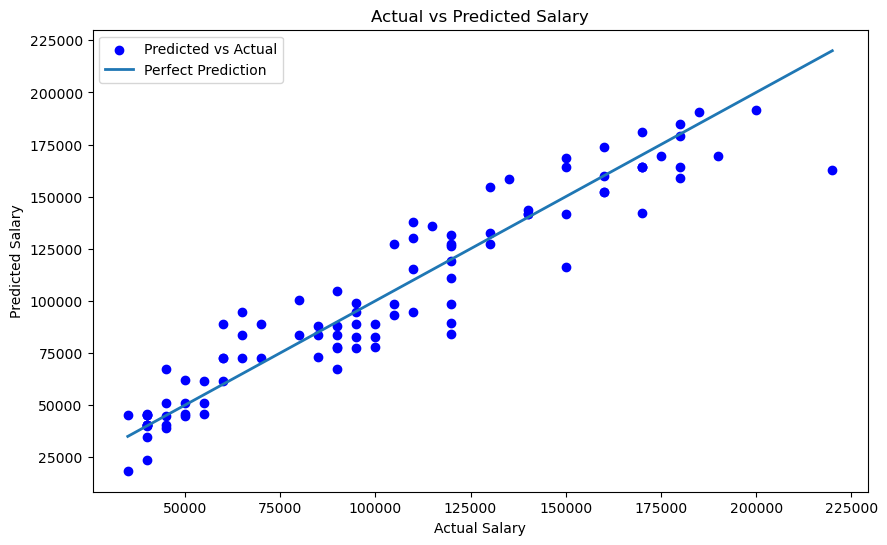

In [79]:
# line draw
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], lw=2, label='Perfect Prediction')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.legend()
plt.show()

In [81]:
# Inference on the trained Model

import pandas as pd
import gradio as gr

def predict_salary(age, gender, education_level):

    # Create input dataframe
    input_df = pd.DataFrame({
        'Age': [age],
        'Gender': [gender],
        'Education Level': [education_level]
    })

    # Apply preprocessing
    input_transformed = ct.transform(input_df)

    # Convert to dataframe
    all_cols = list(ohe_encoded_cols) + list(ordinal_encoded_cols) + remaining_cols

    input_transformed_df = pd.DataFrame(
        input_transformed,
        columns=all_cols
    )

    # Scale age
    input_transformed_df[['Age']] = scaler.transform(
        input_transformed_df[['Age']]
    )

    # Select RFE features
    input_final = input_transformed_df[selected_features]

    # Predict salary
    prediction = lr.predict(input_final)

    return f"Estimated Salary: ${prediction[0]:,.2f}"


gr.Interface(
    fn=predict_salary,
    inputs=[
        gr.Number(label="Age"),
        gr.Dropdown(
            choices=["Male", "Female"],
            label="Gender"
        ),
        gr.Dropdown(
            choices=["Bachelor's", "Master's", "PhD"],
            label="Education Level"
        )
    ],
    outputs=gr.Textbox(label="Predicted Salary"),
    flagging_mode="never"
).launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


C:\Users\onc\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
C:\Users\onc\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
C:\Users\onc\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
C:\Users\onc\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


In [82]:
df.iloc[34]

Age                      46
Gender                 Male
Education Level         PhD
Salary             170000.0
Name: 34, dtype: object